# Retail Sales Data - Exploratory Data Analysis

## 1. Import Libraries and Load Dataset

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load dataset
df = pd.read_csv("realistic_e_commerce_sales_data.csv")

In [4]:
# Display first 5 rows
df.head()

,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,Shipping Status,Order Date
0,CUST0268,Male,North,NaN,Monitor,Electronics,300.0,5,1500,13.31,Returned,2023-12-08
1,CUST0046,Male,West,22.0,Headphones,Accessories,100.0,2,200,6.93,In Transit,2023-04-09
2,CUST0169,Female,South,54.0,Monitor,Electronics,300.0,1,300,11.31,Returned,2023-08-28
3,CUST0002,Male,North,23.0,Headphones,Accessories,100.0,5,500,12.22,Delivered,2023-01-18
4,CUST0173,Female,South,NaN,Laptop,Electronics,1500.0,3,4500,5.40,Delivered,2023-01-19


## Dataset Overview

In [5]:
# Shape of the dataset
df.shape

(1000, 12)

In [6]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer ID      1000 non-null   str    
 1   Gender           1000 non-null   str    
 2   Region           950 non-null    str    
 3   Age              900 non-null    float64
 4   Product Name     1000 non-null   str    
 5   Category         1000 non-null   str    
 6   Unit Price       1000 non-null   float64
 7   Quantity         1000 non-null   int64  
 8   Total Price      1000 non-null   int64  
 9   Shipping Fee     1000 non-null   float64
 10  Shipping Status  950 non-null    str    
 11  Order Date       1000 non-null   str    
dtypes: float64(3), int64(2), str(7)
memory usage: 93.9 KB


In [7]:
# Check missing values
df.isnull().sum()

Customer ID          0
Gender               0
Region              50
Age                100
Product Name         0
Category             0
Unit Price           0
Quantity             0
Total Price          0
Shipping Fee         0
Shipping Status     50
Order Date           0
dtype: int64

### Observation

- The dataset contains **1000 rows** and **12 columns**.
- The dataset includes numerical, categorical, and date-related variables suitable for retail sales analysis.
- Missing values are present in the **Region (50)**, **Age (100)**, and **Shipping Status (50)** columns.
- The dataset is suitable for exploratory data analysis after handling the missing values appropriately.

## 2. Descriptive Statistics

In [8]:
# Numerical columns
numerical_df = df.select_dtypes(include="number")

# Descriptive statistics
pd.DataFrame({
    "Mean": numerical_df.mean(),
    "Median": numerical_df.median(),
    "Mode": numerical_df.mode().iloc[0],
    "Standard Deviation": numerical_df.std()
})

,Mean,Median,Mode,Standard Deviation
Age,46.695556,49.000,66.00,15.011400
Unit Price,457.703777,200.000,300.00,537.231434
Quantity,3.008000,3.000,3.00,1.404246
Total Price,1346.600000,600.000,200.00,1834.037877
Shipping Fee,12.416390,12.315,9.26,4.412185


## 3. Time Series Analysis

In [9]:
# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [10]:
# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

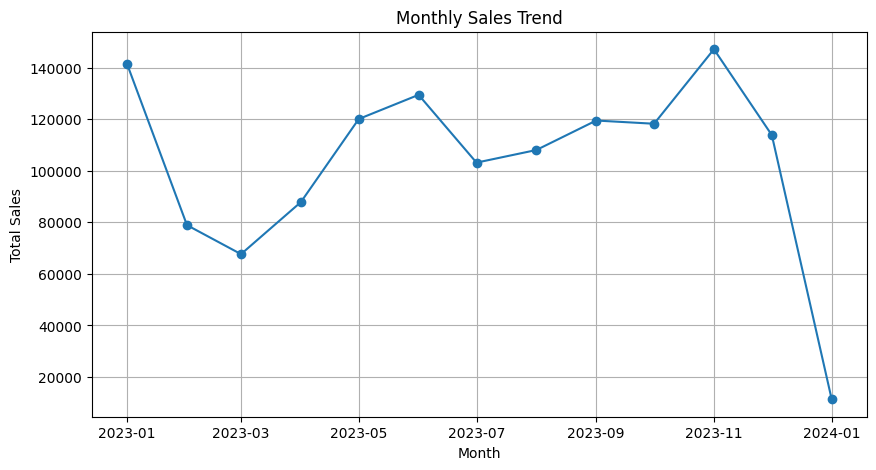

In [11]:
# Monthly sales trend
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Total Price"].sum()

# Convert PeriodIndex to Timestamp for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

# Plot
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

### Observation

- The monthly sales trend shows how total sales vary over different months.
- Peaks indicate months with higher sales, while dips represent periods of lower sales activity.

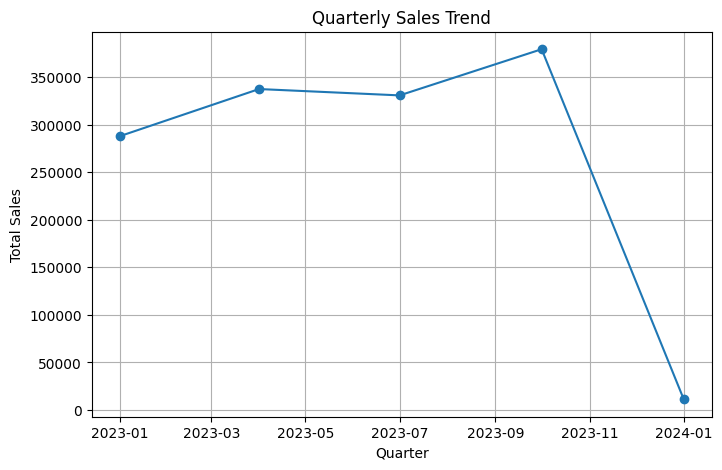

In [12]:
# Quarterly sales trend
quarterly_sales = df.groupby(df["Order Date"].dt.to_period("Q"))["Total Price"].sum()

# Convert PeriodIndex to Timestamp
quarterly_sales.index = quarterly_sales.index.to_timestamp()

# Plot
plt.figure(figsize=(8,5))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker='o')
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

### Observation

- The quarterly sales trend provides a broader view of sales performance over time.
- It helps identify seasonal patterns and overall business growth or decline across quarters.

## 4. Customer Demographics Analysis

In [ ]:
# Create age groups
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=["0-18", "19-30", "31-45", "46-60", "60+"]
)

df["Age Group"].value_counts()

Age Group
46-60    289
31-45    228
60+      206
19-30    159
0-18      18
Name: count, dtype: int64

Why use pd.cut()?

THe assignment asks for customer age groups, not individual ages.

pd.cut() converts ages like:

Age	Age Group
22	19-30
37	31-45
51	46-60
68	60+

This makes the bar chart much easier to interpret than plotting every individual age. It also aligns well with the assignment wording.

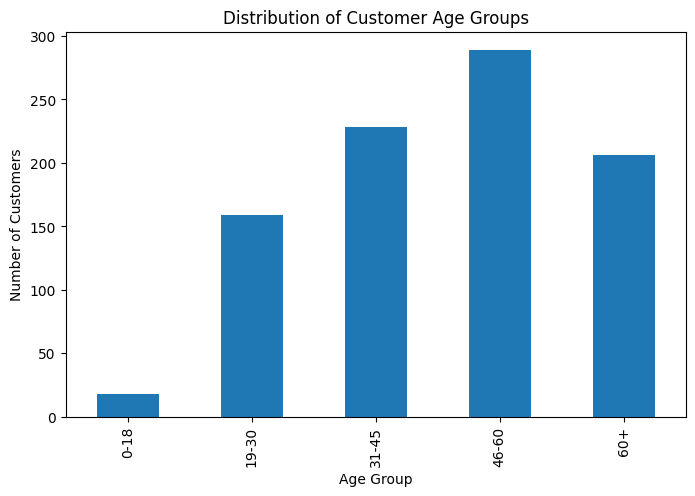

In [15]:
# Distribution of customer age groups
plt.figure(figsize=(8,5))
df["Age Group"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Customer Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.show()

### Observation

- The chart shows the distribution of customers across different age groups.
- The age group with the highest number of customers represents the primary target customer segment.

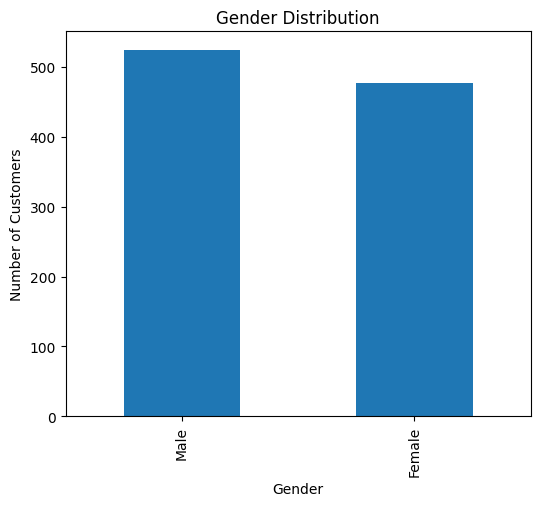

In [17]:
# Gender distribution
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6,5))
gender_counts.plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

### Observation

- The gender distribution shows the number of male and female customers.
- The business can use this information to understand its customer demographics and plan targeted marketing strategies.

## 5. Product Analysis

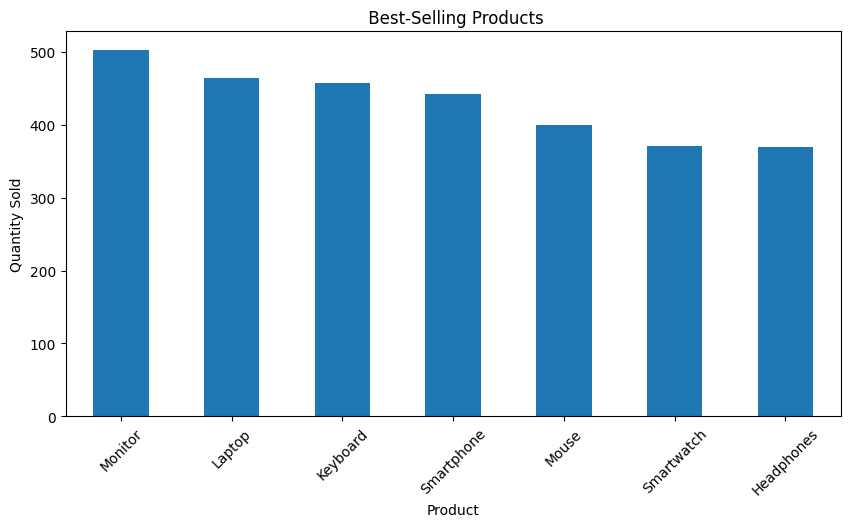

In [27]:
# Top 10 best-selling products
top_products = df.groupby("Product Name")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar")

plt.title(" Best-Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

### Observation

- The heatmap shows the correlation between the numerical variables in the dataset.
- **Unit Price** and **Total Price** have a **strong positive correlation (0.82)**, indicating that higher unit prices generally result in higher total order values.
- **Quantity** has a **moderate positive correlation (0.36)** with **Total Price**, suggesting that purchasing more items increases the total price.
- **Age** and **Shipping Fee** have **very weak correlations** with the other variables, indicating that they have little influence on the sales-related metrics in this dataset.

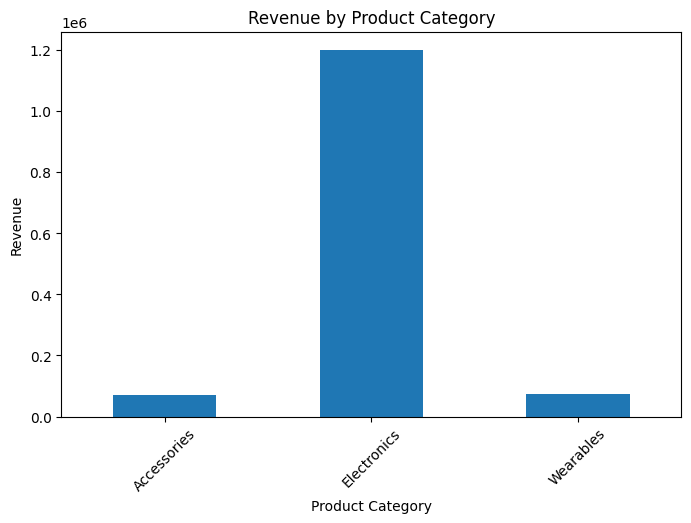

In [28]:
# Revenue by product category
category_revenue = df.groupby("Category")["Total Price"].sum()

plt.figure(figsize=(8,5))
category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## 6. Correlation Matrix Heatmap

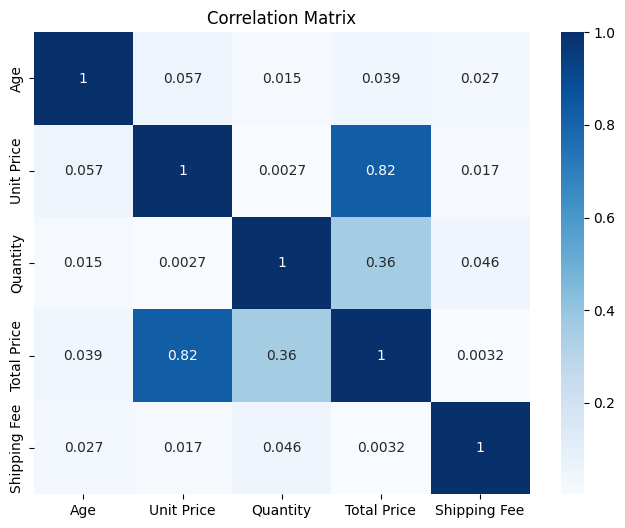

In [29]:
# Correlation matrix for numerical variables
correlation_matrix = df.select_dtypes(include="number").corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="Blues")

plt.title("Correlation Matrix")
plt.show()

### Observation

- The heatmap illustrates the correlation between all numerical variables.
- **Price** and **Total Price** show a strong positive correlation, indicating that higher-priced products generally result in higher order values.
- **Age** has little to no correlation with the sales-related variables, suggesting that customer age does not strongly influence purchase amount in this dataset.

## 7. Additional Visualization: Revenue by Customer Age Group

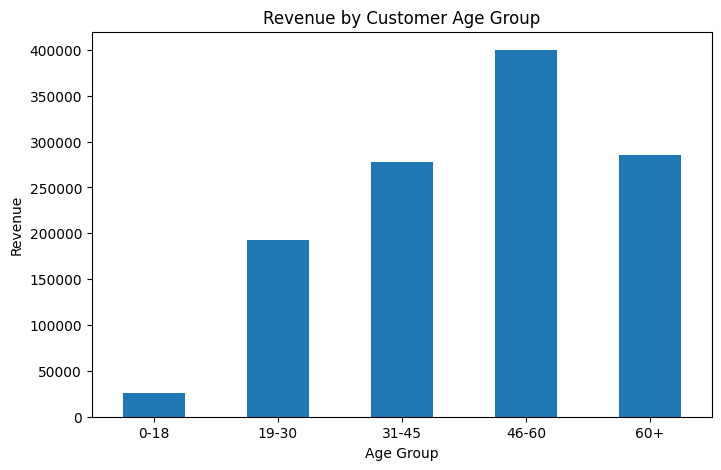

In [30]:
# Revenue by age group
age_group_revenue = df.groupby("Age Group")["Total Price"].sum()

plt.figure(figsize=(8,5))
age_group_revenue.plot(kind="bar")

plt.title("Revenue by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

### Observation

- Customers in the **46–60** age group generate the **highest revenue**, making them the most valuable customer segment.
- Customers aged **31–45** and **60+** also contribute significantly to total revenue.
- The **0–18** age group contributes the least revenue, indicating that this segment has comparatively lower purchasing power or fewer transactions.
- These results suggest that marketing campaigns and premium product offerings should primarily target customers aged **46–60** to maximize revenue.

# 8. Conclusion and Business Recommendations

### Conclusion

Based on the exploratory data analysis, the following business recommendations are proposed:

1. **Target customers aged 46–60** with personalized promotions and loyalty programs, as they generate the highest revenue among all age groups.

2. **Ensure adequate stock of the best-selling products** to avoid stock shortages and improve customer satisfaction.

3. **Increase marketing efforts for the highest-revenue product categories** to maximize sales and profitability.

4. **Use monthly and quarterly sales trends for inventory planning and demand forecasting**, helping the business prepare for periods of high and low sales.

5. **Expand the product range for customers aged 46–60**, as this age group generates the highest revenue. Introducing products that match their preferences and purchasing behavior can help increase sales and customer satisfaction.